## Session 23 - IBM HR Analytics Employee Attrition & Performance
#### Link of Dataset : https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

In [9]:
'''
Import Required Libraries
'''

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

In [10]:
'''
Load Dataset
'''

# Load dataset
df = pd.read_csv("Employee-Attrition.csv")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

First 5 Rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wor

In [13]:
'''
Data Cleaning & Preprocessing
'''

# Drop unnecessary columns
df.drop(["id", "Unnamed: 32"], axis=1, inplace=True)

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Encode Target Variable
# M = 1 (Malignant)
# B = 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

# Separate Features and Target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst 5 Rows:")
print(X.head())

Duplicate Rows: 0

Shape of X: (569, 30)
Shape of y: (569,)

First 5 Rows:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimens

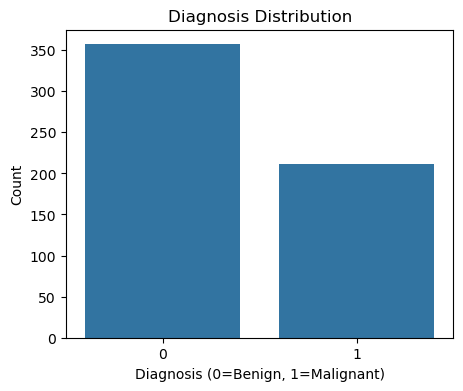

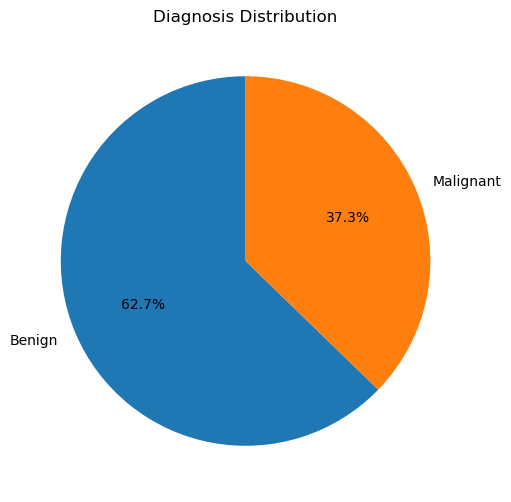

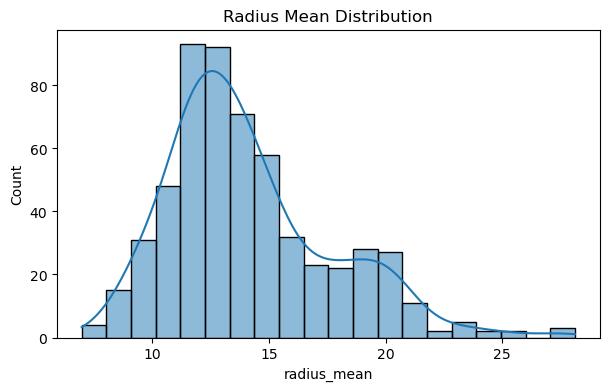

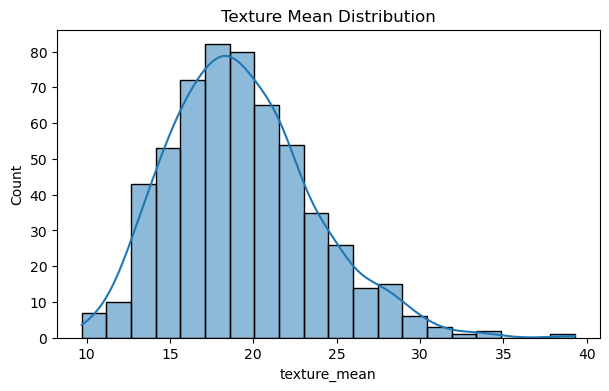

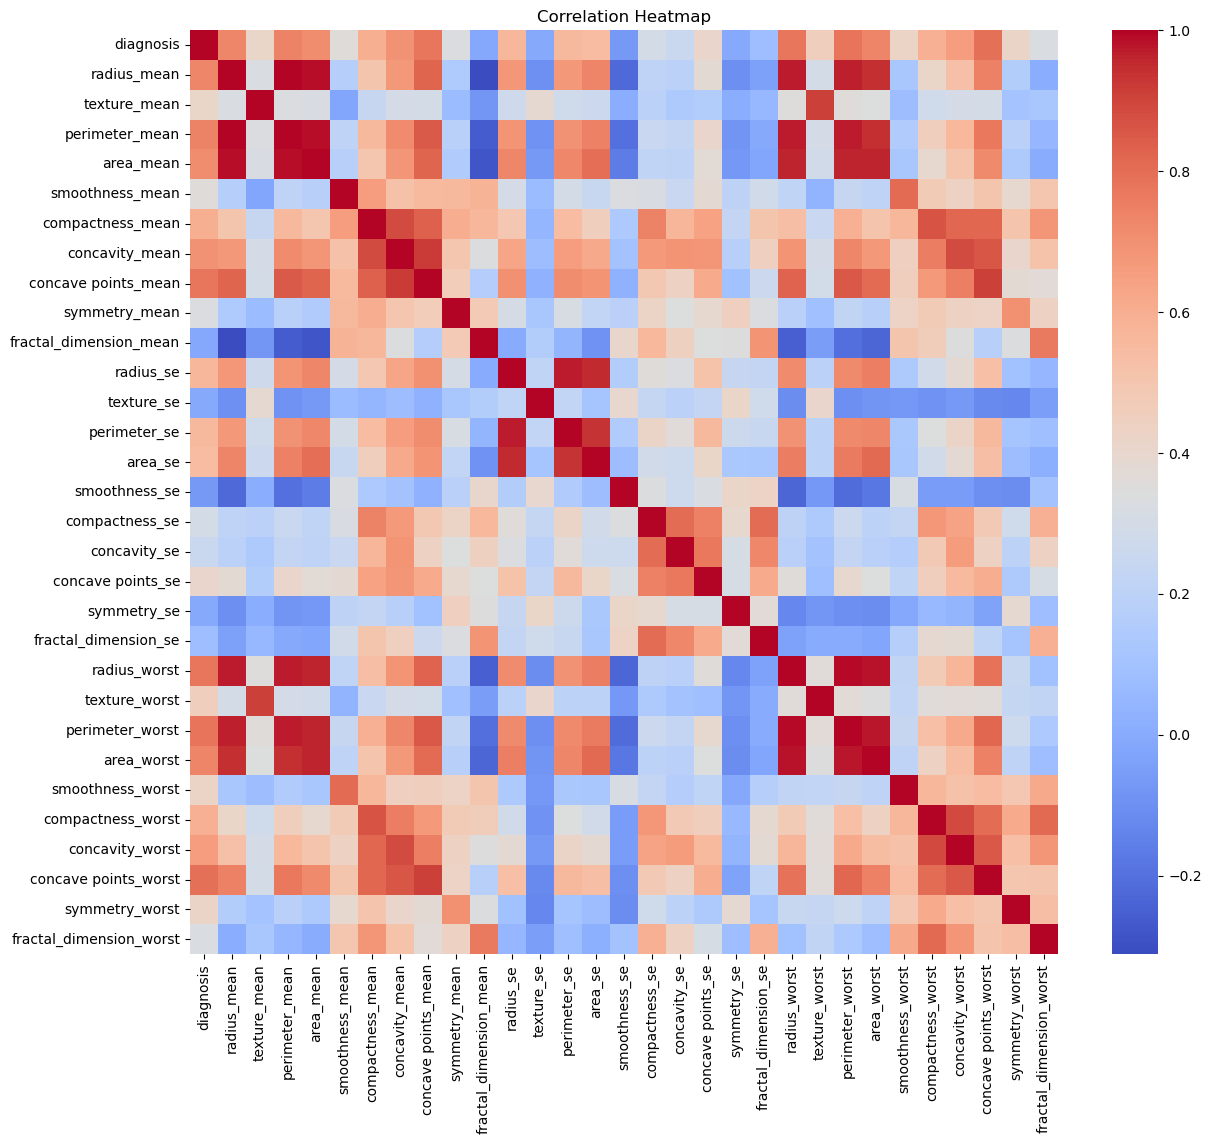

In [14]:
'''
Exploratory Data Analysis
'''

# Diagnosis Distribution
plt.figure(figsize=(5,4))
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis (0=Benign, 1=Malignant)")
plt.ylabel("Count")
plt.show()

# Pie Chart
plt.figure(figsize=(6,6))
df["diagnosis"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Benign","Malignant"],
    startangle=90
)
plt.title("Diagnosis Distribution")
plt.ylabel("")
plt.show()

# Radius Mean Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["radius_mean"], bins=20, kde=True)
plt.title("Radius Mean Distribution")
plt.show()

# Texture Mean Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["texture_mean"], bins=20, kde=True)
plt.title("Texture Mean Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(14,12))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
'''
Feature Scaling
'''

from sklearn.preprocessing import StandardScaler

# Save column names
columns = X.columns

# Scale Features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


In [16]:
'''
Train-Test Split
'''

from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (455, 30)
X_test Shape  : (114, 30)
y_train Shape : (455,)
y_test Shape  : (114,)


In [17]:
'''
Q2. Logistic Regression
'''

from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [18]:
'''
Prediction
'''

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_lr[:10])

First 10 Actual Values:
[0 1 0 1 0 0 1 0 0 0]

First 10 Predicted Values:
[0 1 0 1 1 0 1 0 0 0]


In [19]:
'''
Evaluation Metrics
'''

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.9649
Precision: 0.975
Recall   : 0.9286
F1 Score : 0.9512

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [20]:
'''
Q3. K-Nearest Neighbors (KNN)
'''

# Dictionary to store accuracy
accuracy_scores = {}

# Try different values of k
for k in [3, 5, 7]:

    # Create model
    knn_model = KNeighborsClassifier(n_neighbors=k)

    # Train model
    knn_model.fit(X_train, y_train)

    # Predict
    y_pred_knn = knn_model.predict(X_test)

    # Calculate Accuracy
    accuracy_scores[k] = accuracy_score(y_test, y_pred_knn)

    print(f"k = {k} --> Accuracy = {accuracy_scores[k]:.4f}")

k = 3 --> Accuracy = 0.9386
k = 5 --> Accuracy = 0.9561
k = 7 --> Accuracy = 0.9561


In [21]:
'''
Best Value of k
'''

best_k = max(accuracy_scores, key=accuracy_scores.get)

print("Best k:", best_k)
print("Best Accuracy:", round(accuracy_scores[best_k], 4))

Best k: 5
Best Accuracy: 0.9561


In [22]:
'''
Train Final KNN Model
'''

knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Model Trained Successfully.")

KNN Model Trained Successfully.


In [23]:
'''
Evaluation Metrics
'''

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1 Score :", round(f1_knn, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

Accuracy : 0.9561
Precision: 0.9744
Recall   : 0.9048
F1 Score : 0.9383

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [24]:
'''
Q4. Naive Bayes
'''

from sklearn.naive_bayes import GaussianNB

# Create model
nb_model = GaussianNB()

# Train model
nb_model.fit(X_train, y_train)

print("Naive Bayes Model Trained Successfully.")

Naive Bayes Model Trained Successfully.


In [25]:
'''
Prediction
'''

y_pred_nb = nb_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_nb[:10])

First 10 Actual Values:
[0 1 0 1 0 0 1 0 0 0]

First 10 Predicted Values:
[0 1 0 0 0 1 1 0 0 0]


In [26]:
'''
Evaluation Metrics
'''

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1 Score :", round(f1_nb, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Accuracy : 0.9211
Precision: 0.9231
Recall   : 0.8571
F1 Score : 0.8889

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



In [27]:
'''
Q5. Algorithm Comparison
'''

comparison = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        f"KNN (k={best_k})",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy,
        accuracy_knn,
        accuracy_nb
    ],
    "Precision": [
        precision,
        precision_knn,
        precision_nb
    ],
    "Recall": [
        recall,
        recall_knn,
        recall_nb
    ],
    "F1 Score": [
        f1,
        f1_knn,
        f1_nb
    ]
})

comparison = comparison.round(4)

print(comparison)

             Algorithm  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9649     0.9750  0.9286    0.9512
1            KNN (k=5)    0.9561     0.9744  0.9048    0.9383
2          Naive Bayes    0.9211     0.9231  0.8571    0.8889


In [28]:
'''
Best Performing Algorithm
'''

best_algorithm = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Algorithm"
]

print("Best Performing Algorithm:", best_algorithm)

print("\nReason:")
print("- Highest Accuracy among all models.")
print("- Better Precision, Recall, and F1 Score.")
print("- More suitable for Breast Cancer Classification.")

Best Performing Algorithm: Logistic Regression

Reason:
- Highest Accuracy among all models.
- Better Precision, Recall, and F1 Score.
- More suitable for Breast Cancer Classification.


In [29]:
'''
Save Models
'''

import joblib

# Save Models
joblib.dump(lr_model, "logistic_model.pkl")
joblib.dump(knn_model, "knn_model.pkl")
joblib.dump(nb_model, "naive_bayes_model.pkl")

# Save Scaler
joblib.dump(scaler, "scaler.pkl")

# Save Column Names
joblib.dump(columns, "columns.pkl")

print("Models Saved Successfully.")

Models Saved Successfully.
